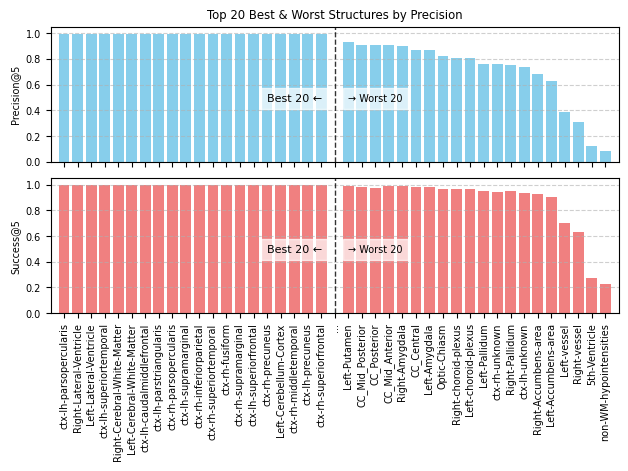

In [9]:
import json
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# Set plot style and font size for clarity
plt.style.use('default')
plt.rcParams.update({'font.size': 7})

only_show_top = 20

# Load metrics.json
with open("data/results/region_brain/eval_cl32/metrics.json", "r") as f:
    metrics = json.load(f)

# Extract precision and success at top_5
results = []
for structure, vals in metrics.items():
    top5 = vals["standard"]["top_5"]
    results.append({
        "structure": structure,
        "precision": top5["precision@k"],
        "success": top5["success@k"],
    })

# Sort by precision
results_sorted = sorted(results, key=lambda x: x["precision"], reverse=True)

# Select top 20 and bottom 20
top20 = results_sorted[:only_show_top]
bottom20 = results_sorted[-only_show_top:]

# Insert a gap placeholder
gap_entry = {"structure": "...", "precision": np.nan, "success": np.nan}
subset = top20 + [gap_entry] + bottom20

# Extract for plotting
structures = [r["structure"] for r in subset]
precisions = [r["precision"] for r in subset]
successes = [r["success"] for r in subset]

# Convert cm → inches
cm = 1/2.54
fig, axes = plt.subplots(2, 1, figsize=(16*cm, 12*cm), sharex=True)

# Precision subplot
axes[0].bar(range(len(subset)), precisions, color="skyblue")
axes[0].set_ylabel("Precision@5")
axes[0].set_title("Top 20 Best & Worst Structures by Precision")
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

# Success subplot
axes[1].bar(range(len(subset)), successes, color="lightcoral")
axes[1].set_ylabel("Success@5")
axes[1].set_xticks(range(len(subset)))
axes[1].set_xticklabels(structures, rotation=90)
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

# Add labels for groups
ymax0 = axes[0].get_ylim()[1]
ymax1 = axes[1].get_ylim()[1]

sep_index = len(top20)
for ax in axes:
    ax.axvline(sep_index, color="black", linestyle="--", alpha=0.8, linewidth=1)
    t1 = ax.text(only_show_top-3, ymax0*0.45, f"Best {only_show_top} ←", ha="center", fontsize=8)
    t1.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='white'))
    t2 = ax.text(len(subset)-only_show_top+2, ymax0*0.45, f"→ Worst {only_show_top}", ha="center")
    t2.set_bbox(dict(facecolor='white', alpha=0.7, edgecolor='white'))
    ax.set_xlim([-1,only_show_top*2+1])
    ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig(f"figures/top_20_structures.pdf", format='pdf', bbox_inches='tight')
plt.show()

**FIGURE: EXAMPLE OF INPUT - GT FOR BRAIN STRUCTURES**

In [10]:
from preprocessing.load_dataset import SubCorBatDataset
import pandas as pd
import os

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]

# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"original/dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels

# Training configuration
batch_files = sorted(metadata["batch_file"].unique())

# Load labels and bounding boxes
labels_df = pd.read_csv("data/labels.csv")
bb_df = pd.read_csv("data/bounding_boxes.csv")
labels_bb_df = pd.merge(labels_df, bb_df, on="LabelName", how="inner") # Merge on the 'GUID' column

batch_files = batch_files[-4:-3] # To only load ABLI
print(batch_files)

from preprocessing.load_dataset import SingleStructDataset
dataset = SingleStructDataset(metadata, batch_files, labels_bb_df, target_struct_name="Left-Hippocampus")

guids = np.array(dataset.guids)

METADATA: Original rows: 26685
METADATA: Remaining rows: 26685
['/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/batched_aibl/batch_0002.npz']


In [11]:
df = []
for guid in guids:
    subject_id = dataset.metadata.query(f"GUID == '{guid}'")[["subject"]].values[0, 0]
    df.append([guid, subject_id])
df = pd.DataFrame(df, columns=['GUID', 'subject'])
counts = df.groupby('subject').count().sort_values(by="GUID",ascending=False)
print()


N guid in subject: 4


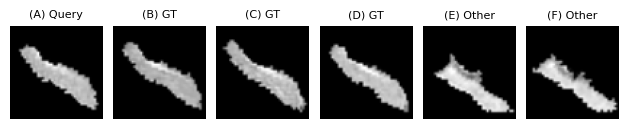

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torch

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Pick one subject (query subject)
idx = 1
subject_id = counts.iloc[idx].name
subject_guids = df.query(f"subject == '{subject_id}'").GUID.to_list()
print(f"N guid in subject: {len(subject_guids)}")

# Get dataset indices for this subject
i_subs = [np.where(guids == g)[0][0] for g in subject_guids]

# Pick another subject (different from query)
other_subject_id = counts.iloc[idx+3].name
other_subject_guids = df.query(f"subject == '{other_subject_id}'").GUID.to_list()
i_subs_other = [np.where(guids == g)[0][0] for g in other_subject_guids]

# --- Select which samples to plot ---
# Query = first scan of subject
query_idx = i_subs[0]

# Ground truth = next 3 scans of same subject (if available)
gt_indices = i_subs[1:4]

# Other = 2 scans from another subject
other_indices = i_subs_other[:2]

# Final sequence of indices
plot_indices = [query_idx] + gt_indices + other_indices

# --- Plot axial slices only ---
cm = 1/2.54
fig, axes = plt.subplots(1, 6, figsize=(16*cm, 5*cm))

for ax, i_sub in zip(axes, plot_indices):
    sample = dataset[i_sub]
    struct = sample["image"][0]  # shape [D, H, W]

    # find best axial slice (z axis)
    z_profile = struct.sum(axis=(1, 2))
    z_max = torch.argmax(z_profile).item()
    axial = struct[z_max, :, :].cpu()

    ax.imshow(axial, cmap="gray")
    ax.axis("off")

    # label query vs GT vs other
    subj = dataset.metadata.query(f"GUID == '{sample['GUID']}'")[["subject"]].values[0, 0]
    ax.set_title(f"{sample['GUID']}\nsubj {subj}", fontsize=7)

axes[0].set_title("(A) Query", fontsize=8)
axes[1].set_title("(B) GT", fontsize=8)
axes[2].set_title("(C) GT", fontsize=8)
axes[3].set_title("(D) GT", fontsize=8)
    
axes[4].set_title("(E) Other", fontsize=8)
axes[5].set_title("(F) Other", fontsize=8)

plt.tight_layout()
plt.savefig(f"figures/example_structures_sample.pdf", format='pdf', bbox_inches='tight')
plt.show()


**FIGURE: EXAMPLE OF INPUT - GT FOR WHOLE BRAIN**

In [13]:
locals()

{'__name__': '__main__',
 '__doc__': 'Automatically created module for IPython interactive environment',
 '__package__': None,
 '__loader__': None,
 '__spec__': None,
 '__builtin__': <module 'builtins' (built-in)>,
 '__builtins__': <module 'builtins' (built-in)>,
 '_ih': ['',
  'import json\nimport matplotlib.pyplot as plt\nimport numpy as np\nget_ipython().run_line_magic(\'matplotlib\', \'inline\')\n\n# Set plot style and font size for clarity\nplt.style.use(\'default\')\nplt.rcParams.update({\'font.size\': 7})\n\nonly_show_top = 20\n\n# Load metrics.json\nwith open("data/results/region_brain/eval_cl32/metrics.json", "r") as f:\n    metrics = json.load(f)\n\n# Extract precision and success at top_5\nresults = []\nfor structure, vals in metrics.items():\n    top5 = vals["standard"]["top_5"]\n    results.append({\n        "structure": structure,\n        "precision": top5["precision@k"],\n        "success": top5["success@k"],\n    })\n\n# Sort by precision\nresults_sorted = sorted(resul

In [14]:
if "dataset" in locals():
    del dataset

from preprocessing.load_dataset import LookupNPZDataset
import pandas as pd
import os

### Input data
# Path to dataset
DATA_PATH = "/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/"
load_ds_path = DATA_PATH + "batched_adni/"
# Files to load/save extension
extension = ".npz"
# Pretrained weights for the VAE
ckpt_vae_path = ""#"./data/pretrained_models/autoencoder_puglisi.pth"
# Pretrained weights for the Discriminator
ckpt_dis_path = ""#"./data/pretrained_models/ckpt_dis_.pth"
# Preparing image for using as input of the VAE
target_shape = [1, 160, 224, 160] # Desired shape: [1, 160, 224, 160]

# Load metadata
index_ds = pd.read_csv(os.path.join(DATA_PATH,"original/dataset_index.csv"))
clinical_ds = pd.read_csv(os.path.join(DATA_PATH,"combined_metadata.csv"))
metadata = pd.merge(index_ds, clinical_ds, on="GUID", how="inner") # Merge on the 'GUID' column
print(f"METADATA: Original rows: {len(metadata)}")

# First, ensure empty strings are treated as NaN
metadata['subject'].replace('', pd.NA, inplace=True)

# Then drop rows where subject is NaN
metadata = metadata.dropna(subset=['subject'])

# Optional: reset index
metadata = metadata.reset_index(drop=True)
print(f"METADATA: Remaining rows: {len(metadata)}") # Check result

# Load labels

# Training configuration
batch_files = sorted(metadata["batch_file"].unique())
batch_files = batch_files[-4:-3] # To only load ABLI
batch_file = batch_files[0]
print(batch_files)

from preprocessing.load_dataset import SingleStructDataset
dataset = LookupNPZDataset(metadata, batch_file=batch_file, use_segmentation=False)

guids = np.array(dataset.guids)

METADATA: Original rows: 26685
METADATA: Remaining rows: 26685
['/mimer/NOBACKUP/groups/naiss2025-23-412/felixnie/batched_datasets/original/batched_aibl/batch_0002.npz']


In [15]:
df = []
for guid in guids:
    subject_id = dataset.metadata.query(f"GUID == '{guid}'")[["subject"]].values[0, 0]
    df.append([guid, subject_id])
df = pd.DataFrame(df, columns=['GUID', 'subject'])
counts = df.groupby('subject').count().sort_values(by="GUID",ascending=False)
print()

N guid in subject: 4


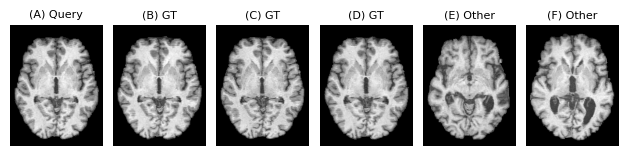

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torch

plt.style.use('default')
plt.rcParams.update({'font.size': 7})

# Pick one subject (query subject)
idx = 1
subject_id = counts.iloc[idx].name
subject_guids = df.query(f"subject == '{subject_id}'").GUID.to_list()
print(f"N guid in subject: {len(subject_guids)}")

# Get dataset indices for this subject
i_subs = [np.where(guids == g)[0][0] for g in subject_guids]

# Pick another subject (different from query)
other_subject_id = counts.iloc[idx+3].name
other_subject_guids = df.query(f"subject == '{other_subject_id}'").GUID.to_list()
i_subs_other = [np.where(guids == g)[0][0] for g in other_subject_guids]

# --- Select which samples to plot ---
# Query = first scan of subject
query_idx = i_subs[0]

# Ground truth = next 3 scans of same subject (if available)
gt_indices = i_subs[1:4]

# Other = 2 scans from another subject
other_indices = i_subs_other[:2]

# Final sequence of indices
plot_indices = [query_idx] + gt_indices + other_indices

# --- Plot axial slices only ---
cm = 1/2.54
fig, axes = plt.subplots(1, 6, figsize=(16*cm, 5*cm))

for ax, i_sub in zip(axes, plot_indices):
    sample = dataset[i_sub]
    struct = sample["image"][0]  # shape [D, H, W]

    # find best axial slice (z axis)
    # z_profile = struct.sum(axis=(1, 2))
    # z_max = torch.argmax(z_profile).item()
    # axial = struct[z_max, :, :].cpu()

    z_profile = struct.sum(axis=(0, 2))
    z_max = torch.argmax(z_profile).item()
    axial = struct[:, z_max, :].cpu()

    ax.imshow(axial.T.flip(0), cmap="gray")
    ax.axis("off")

    # label query vs GT vs other
    subj = dataset.metadata.query(f"GUID == '{sample['GUID']}'")[["subject"]].values[0, 0]
    ax.set_title(f"{sample['GUID']}\nsubj {subj}", fontsize=7)

axes[0].set_title("(A) Query", fontsize=8)
axes[1].set_title("(B) GT", fontsize=8)
axes[2].set_title("(C) GT", fontsize=8)
axes[3].set_title("(D) GT", fontsize=8)
    
axes[4].set_title("(E) Other", fontsize=8)
axes[5].set_title("(F) Other", fontsize=8)

plt.tight_layout()
plt.savefig(f"figures/example_brain_sample.pdf", format='pdf', bbox_inches='tight')
plt.show()
